# TP  Représentation du texte pour la classification de sentiments

  <table style="margin: 0 auto; color: white; font-size: 0.95em;">
    <tr><td style="padding:4px 20px;"><b>Établissement</b></td><td>ENSAM — Université Hassan II de Casablanca</td></tr>
    <tr><td style="padding:4px 20px;"><b>Année</b></td><td>2025 – 2026</td></tr>
    <tr><td style="padding:4px 20px;"><b>Cours</b></td><td>NLP — Traitement du Langage Naturel</td></tr>
    <tr><td style="padding:4px 20px;"><b>Dataset fil rouge</b></td><td>IMDb Movie Reviews (50 000 critiques)</td></tr>
    <tr><td style="padding:4px 20px;"><b>Tâche</b></td><td>Classification de sentiment : Positif / Négatif</td></tr>
  </table>

Ce notebook propose une mise en pratique progressive autour d’un problème classique de NLP : **classer des avis positifs ou négatifs à partir de leur texte**.

L’objectif pédagogique est double :
1. comprendre la logique des représentations textuelles ;
2. comparer, sur un même corpus, des approches de complexité croissante.

Vous pouvez travailler sur :
- **IMDb** (`IMDB Dataset of 50K Movie Reviews`) ;
    - https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews

- ou un **corpus personnel** en classification supervisée.

Le travail suit une progression expérimentale :
**exploration → préparation → vectorisation → classification → évaluation → interprétation**.

### Conseils méthodologiques

Quelques principes à garder:
- une bonne représentation dépend de la tâche ;
- une meilleure représentation n’est pas toujours plus interprétable ;
- les gains de performance doivent être mis en regard du coût de calcul ;
- les erreurs observées sont souvent plus instructives que le score final.

### Librairies nécessaires
| Librairie | Rôle |
|-----------|------|
| `scikit-learn` | TF-IDF, BoW, métriques d'évaluation |
| `gensim` | Word2Vec, GloVe, FastText |
| `transformers` | BERT et modèles HuggingFace |
| `torch` | Backend pour BERT |
| `datasets` | Chargement du dataset IMDb depuis HuggingFace |
| `matplotlib / seaborn` | Visualisations |

In [1]:
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

random.seed(42)
np.random.seed(42)

## 1. Cadre expérimental

Avant toute modélisation, clarifiez le cadre de travail.

### Questions
- Quel corpus est utilisé ?
- Quelle est la variable cible ?
- Travaillez-vous sur l’ensemble du corpus ou sur un sous-échantillon ?
- Les classes sont-elles équilibrées ?

### Point méthodologique
Pour comparer plusieurs représentations, il est préférable de conserver **le même découpage apprentissage / test** pour toutes les expériences.

### Dataset IMDb Movie Reviews

#### Présentation du Dataset

Le dataset **IMDb Movie Reviews** est un référentiel standard du NLP pour l'analyse de sentiment.
Il contient **50 000 critiques de films en anglais**, équitablement réparties entre positif et négatif.

| Caractéristique | Valeur |
|-----------------|--------|
| Source | Internet Movie Database (IMDb) |
| Taille totale | 50 000 critiques |
| Entraînement | 25 000 (50% pos / 50% neg) |
| Test | 25 000 (50% pos / 50% neg) |
| Langue | Anglais |
| Tâche | Classification binaire : Positif (1) / Négatif (0) |
| Référence | Maas et al., 2011 — Stanford NLP |

#### Pourquoi ce dataset ?

Ce dataset est **idéal pour comparer les méthodes** car :
- Il contient de la **négation** : "not good", "not bad" → difficile pour BoW
- Il contient des **synonymes** : "excellent" ≈ "brilliant" → difficile pour TF-IDF
- Il contient des **mots rares et argotiques** → difficile pour Word2Vec
- Il nécessite une **compréhension du contexte** → BERT excelle ici
- Il est **bien équilibré** → métriques fiables

> **Pour faciliter l’expérimentation, vous pouvez travailler sur un sous‑ensemble du jeu de données (par exemple 10 000 à 20 000 exemples)**.

- Colonnes attendues :
    - text : le contenu textuel
    - label : la classe (0/1 ou autre encodage supervisé)

In [2]:
# Option A : charger IMDb depuis Hugging Face
from datasets import load_dataset
dataset = load_dataset("imdb")
train_df = dataset["train"].to_pandas()
test_df = dataset["test"].to_pandas()

# Option B : charger un fichier CSV local
# df = pd.read_csv("votre_fichier.csv")
# df = df.rename(columns={"texte": "text", "label": "label"})

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

### Aide pour un corpus personnel

Si vous utilisez vos propres données, vérifiez que :
- chaque ligne correspond à un document ;
- le texte est bien dans une seule colonne ;
- l’étiquette de classe est disponible ;
- les valeurs manquantes ont été retirées ou traitées.

## 2. Exploration du corpus

### Objectifs
Observer la structure des données avant de les transformer, 

> Une bonne exploration permet souvent d’anticiper les limites des représentations simples.

### Questions
- Combien de mots contiennent les avis, en moyenne ?
- Les textes sont-ils très hétérogènes en longueur ?
- Certaines classes utilisent-elles un vocabulaire plus “marqué” que d’autres ?
- Voyez-vous du bruit textuel utile à nettoyer ?

In [3]:
# Ajustez le nom du DataFrame selon votre cas
df = train_df.copy()

df["length"] = df["text"].astype(str).str.split().apply(len)

display(df["length"].describe())
display(df.groupby("label")["length"].describe())

count    25000.000000
mean       233.787200
std        173.733032
min         10.000000
25%        127.000000
50%        174.000000
75%        284.000000
max       2470.000000
Name: length, dtype: float64

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,12500.0,230.86784,166.663126,10.0,128.0,174.0,278.0,1522.0
1,12500.0,236.70656,180.485743,12.0,125.0,174.0,291.0,2470.0


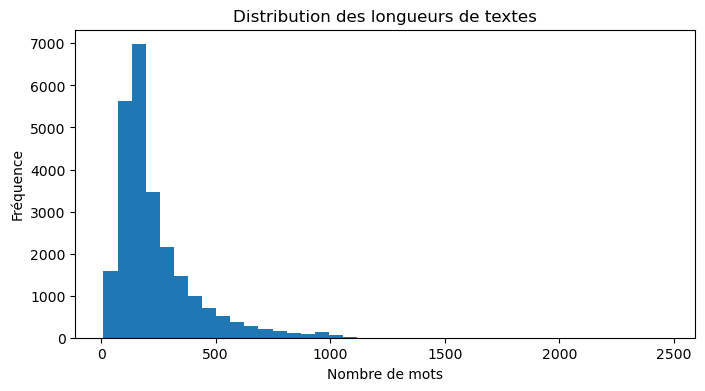

In [4]:
# Distribution des longueurs
plt.figure(figsize=(8, 4))
plt.hist(df["length"], bins=40)
plt.title("Distribution des longueurs de textes")
plt.xlabel("Nombre de mots")
plt.ylabel("Fréquence")
plt.show()

In [5]:
for label in [0, 1]:
    texts = df[df["label"] == label]["text"].tolist()
    tfidf = TfidfVectorizer(max_features=20, stop_words="english")
    tfidf.fit(texts)
    scores = zip(tfidf.get_feature_names_out(),
                 tfidf.idf_)
    top = sorted(scores, key=lambda x: x[1])[:15]
    print(f"\nLabel {label} - mots les plus cractéristiques : ")
    print([word for word, score in top])


Label 0 - mots les plus cractéristiques : 
['movie', 'br', 'film', 'like', 'just', 'good', 'bad', 'time', 'really', 'don', 'make', 'story', 'acting', 'people', 'plot']

Label 1 - mots les plus cractéristiques : 
['br', 'film', 'movie', 'like', 'good', 'just', 'time', 'great', 'story', 'really', 'best', 'way', 'people', 'love', 'life']


In [6]:
df["text"].str.contains("<.*?>").sum()

14667

### Analyse à rédiger

Interpréter les principales observations :
- l’équilibre des classes ;
- la longueur des textes ;
- le niveau de bruit ;
- l’intérêt d’un sous-échantillon si le calcul devient trop coûteux.

## 3. Prétraitement

Le prétraitement doit être justifié. Dans une tâche de sentiment, certaines décisions peuvent être bénéfiques dans un contexte, et nuisibles dans un autre.

### Questions
- Faut-il supprimer les stopwords ?
- Faut-il conserver les négations comme `not`, `no`, `never` ?
- Faut-il conserver l’apostrophe et les contractions ?
- Faut-il normaliser l’écriture en minuscules ?

### Point d’attention

Évitez de retirer automatiquement les mots de négation sans réflexion.  
Dans l’analyse de sentiment, cette décision peut supprimer une information essentielle.

In [7]:
def nettoyer_texte(texte: str) -> str:
    texte = str(texte).lower()
    texte = re.sub(r"<br\s*/?>", " ", texte)
    texte = re.sub(r"[^a-zA-Z\s']", " ", texte)
    texte = re.sub(r"\s+", " ", texte).strip()
    return texte

df["text_clean"] = df["text"].apply(nettoyer_texte)
df[["text", "text_clean"]].head()

,text,text_clean
0,I rented I AM CURIOUS-YELLOW from my video sto...,i rented i am curious yellow from my video sto...
1,"""I Am Curious: Yellow"" is a risible and preten...",i am curious yellow is a risible and pretentio...
2,If only to avoid making this type of film in t...,if only to avoid making this type of film in t...
3,This film was probably inspired by Godard's Ma...,this film was probably inspired by godard's ma...
4,"Oh, brother...after hearing about this ridicul...",oh brother after hearing about this ridiculous...


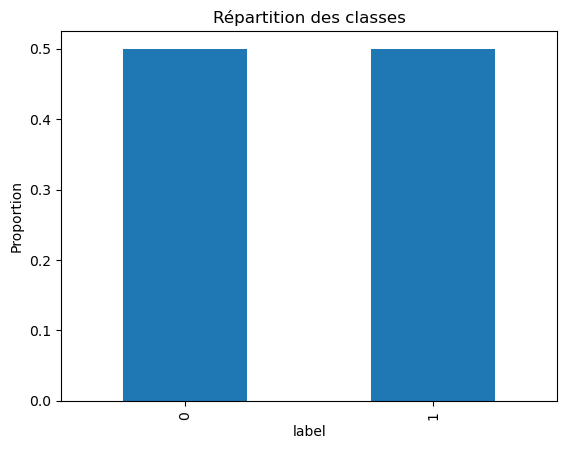

In [8]:
# Répartition des classes
df["label"].value_counts(normalize=True).plot(kind="bar")
plt.title("Répartition des classes")
plt.ylabel("Proportion")
plt.show()

## 4. Protocole de comparaison

Avant de tester les méthodes, mettez en place un cadre commun.

### À conserver constant
- le découpage train/test ;
- le classifieur de base ;
- les métriques ;
- le niveau de prétraitement.

### Pourquoi ?
Ainsi, les écarts observés proviennent principalement de la représentation textuelle, et non d’un changement de protocole.

In [9]:
# Variables de travail
X = df["text_clean"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## 5.  Bag of Words

Le Bag of Words transforme chaque texte en vecteur de fréquences lexicales.

### Questions
- Quelles informations conserve cette représentation ?
- Quelles informations perd-elle ?
- Pourquoi peut-elle rester performante sur IMDb ?
- Quels types d’erreurs peut-elle produire ?

In [10]:
bow_model = Pipeline([
    ("vect", CountVectorizer(max_features=10000)),
    ("clf", LogisticRegression(max_iter=1000))
])

bow_model.fit(X_train, y_train)
y_pred_bow = bow_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred_bow))
print("F1 macro:", f1_score(y_test, y_pred_bow, average="macro"))

Accuracy: 0.875
F1 macro: 0.8749945547628055


In [11]:
# Coefficients les plus influents
vocab = bow_model.named_steps["vect"].get_feature_names_out()
coef = bow_model.named_steps["clf"].coef_[0]

top_pos = np.argsort(coef)[-10:]
top_neg = np.argsort(coef)[:10]

print("Mots les plus associés à la classe positive:")
print(vocab[top_pos])
print("\nMots les plus associés à la classe négative:")
print(vocab[top_neg])

Mots les plus associés à la classe positive:
['excellent' 'shannon' 'vengeance' 'appreciated' 'cerebral' 'perfect'
 'flawless' 'refreshing' 'funniest' 'wonderfully']

Mots les plus associés à la classe négative:
['worst' 'disappointment' 'waste' 'awful' 'poorly' 'lacks' 'fails'
 'baldwin' 'horrible' 'laughable']


### Interprétation guidée

Commentez les résultats en répondant à ces trois points :
1. Le modèle repère-t-il des mots sentimentaux explicites ?
2. Est-il sensible à l’ordre des mots ?
3. Que devient une phrase comme `not good` ?


## 6. N-grams

Les n-grams ajoutent une information partielle sur l’ordre local des mots.

### Questions
- Que gagne-t-on avec les bigrammes ?
- Pourquoi les trigrammes sont-ils souvent plus rares ?
- Quel compromis semble le plus pertinent entre précision et complexité ?

In [12]:
ngram_model = Pipeline([
    ("vect", CountVectorizer(max_features=15000, ngram_range=(1, 2))),
    ("clf", LogisticRegression(max_iter=1000))
])

ngram_model.fit(X_train, y_train)
y_pred_ng = ngram_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred_ng))
print("F1 macro:", f1_score(y_test, y_pred_ng, average="macro"))

Accuracy: 0.8886
F1 macro: 0.8885967514812732


### À observer

Cherchez des expressions fréquentes comme :
- `not good`
- `really bad`
- `highly recommend`
- `waste of time`

Demandez-vous si le modèle les traite mieux que BoW.

## 7. TF-IDF

TF-IDF corrige la simple fréquence par une pondération liée à la rareté du terme dans le corpus.

### Questions
- Quels mots sont naturellement pénalisés ?
- Pourquoi TF-IDF est-il souvent supérieur à BoW ?
- Dans quels cas la différence peut-elle rester faible ?

In [13]:
tfidf_model = Pipeline([
    ("vect", TfidfVectorizer(max_features=15000, ngram_range=(1, 2))),
    ("clf", LogisticRegression(max_iter=1000))
])

tfidf_model.fit(X_train, y_train)
y_pred_tfidf = tfidf_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred_tfidf))
print("F1 macro:", f1_score(y_test, y_pred_tfidf, average="macro"))

Accuracy: 0.8944
F1 macro: 0.8943961982631374


In [14]:
y_test_tdidf = y_test

### Question d’analyse

TF-IDF est-il meilleur parce qu’il “comprend” mieux le texte, ou parce qu’il réduit le poids des mots peu informatifs ?  
Justifiez votre réponse.

## 8. Comparaison des méthodes lexicales

À ce stade, comparez :
- Bag of Words ;
- N-grams ;
- TF-IDF.

### Questions de conclusion
- Quelle méthode offre le meilleur compromis ?
- La meilleure performance est-elle forcément la plus simple à interpréter ?
- Quelle méthode recommanderiez-vous dans un contexte de déploiement rapide ?

In [ ]:
# Tableau à compléter
resultats_lexicaux = pd.DataFrame([
    {"Méthode": "BoW", "Accuracy": bow_acc, "F1_macro": bow_f1},
    {"Méthode": "N-grams", "Accuracy": ngram_accuracy, "F1_macro": ngram_f1},
    {"Méthode": "TF-IDF", "Accuracy": tfidf_acc, "F1_macro": tfidf_f1},
])

display(resultats_lexicaux.sort_values("Accuracy", ascending=False))

NameError: name 'bow_acc' is not defined

## 9. Word Embeddings — Word2Vec

Un embedding dense représente un mot dans un espace vectoriel continu.

### Questions
- Que signifie une proximité entre deux mots dans cet espace ?
- Pourquoi un embedding peut-il capturer de la similarité sémantique ?
- Que perd-on lorsqu’on résume un document par la moyenne de ses vecteurs de mots ?

In [17]:
from gensim.models import Word2Vec

sentences = [str(t).split() for t in df["text_clean"]]
w2v = Word2Vec(sentences=sentences, vector_size=100, window=5, min_count=2, workers=4, sg=1)

> **Visualiser l’espace vectoriel des mots en utilisant t-SNE**


In [18]:
def document_vector(tokens, model, vector_size=100):
    vectors = [model.wv[w] for w in tokens if w in model.wv]
    if len(vectors) == 0:
        return np.zeros(vector_size)
    return np.mean(vectors, axis=0)

X_w2v = np.vstack([
    document_vector(str(t).split(), w2v, 100)
    for t in df["text_clean"]
])

In [19]:
# Classification sur les vecteurs Word2Vec
X_train_w2v, X_test_w2v, y_train, y_test = train_test_split(
    X_w2v, y, test_size=0.2, random_state=42, stratify=y
)

clf_w2v = LogisticRegression(max_iter=1000)
clf_w2v.fit(X_train_w2v, y_train)
y_pred_w2v = clf_w2v.predict(X_test_w2v)

print("Accuracy:", accuracy_score(y_test, y_pred_w2v))
print("F1 macro:", f1_score(y_test, y_pred_w2v, average="macro"))

Accuracy: 0.8362
F1 macro: 0.8361988927045148


### Interprétation guidée

Comparez Word2Vec à TF-IDF :
- Word2Vec apprend-il mieux le sens global ?
- La moyenne des mots est-elle suffisante pour une tâche de sentiment ?
- Les mots rares sont-ils bien représentés ?
- Pourquoi les résultats peuvent-ils rester proches, voire inférieurs, à TF-IDF ?

## 10. FastText

FastText enrichit Word2Vec en intégrant des sous-mots.

### Questions
- En quoi cela aide-t-il pour les mots rares ?
- Pourquoi FastText est-il souvent plus robuste aux fautes d’orthographe ?
- Dans quelles langues cette propriété est-elle particulièrement utile ?

In [20]:
from gensim.models import FastText

ft = FastText(sentences=sentences, vector_size=100, window=5, min_count=2, workers=4, sg=1)

### Comparaison attendue

FastText est-il plus performant parce qu’il comprend mieux les émotions, ou parce qu’il gère mieux les formes inconnues et les variantes morphologiques ?  
Répondez en vous appuyant sur l’observation des corpus.

## 11. Embeddings contextuels — BERT

BERT produit des vecteurs dépendants du contexte. Un mot n’a donc plus un seul vecteur fixe.

### Questions
- Pourquoi la négation est-elle mieux traitée ?
- Pourquoi BERT distingue-t-il mieux les contextes ?
- Qu’apporte le contexte bidirectionnel par rapport à un embedding statique ?

In [21]:
from transformers import AutoTokenizer, AutoModel

model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
bert_model = AutoModel.from_pretrained(model_name)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [22]:
def bert_embeddings(texts, tokenizer, model, max_length=256, batch_size=16):
    import torch
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()

    all_emb = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        enc = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        ).to(device)

        with torch.no_grad():
            out = model(**enc)

        cls_emb = out.last_hidden_state[:, 0, :].cpu().numpy()
        all_emb.append(cls_emb)

    return np.vstack(all_emb)

### Variante pédagogique

Pour limiter le coût de calcul, appliquez BERT sur un sous-échantillon raisonnable du corpus, puis comparez les tendances obtenues avec les méthodes précédentes.

## 12. Évaluation commune

Utilisez les mêmes métriques pour toutes les méthodes testées.

### Métriques recommandées
- accuracy ;
- F1 macro ;
- matrice de confusion.

### Questions
- Quelle métrique reste la plus informative si les classes sont déséquilibrées ?
- Que révèle la matrice de confusion sur les types d’erreurs ?

In [25]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
def evaluer(y_true, y_pred, nom="Modèle"):
    print(f"\n{'='*30}")
    print(f"ÉVALUATION : {nom}")
    print(f"{'='*30}")
    
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro")
    
    print(f"Accuracy : {round(acc, 4)}")
    print(f"F1 macro : {round(f1, 4)}")
    print("\nReport détaillé :")
    print(classification_report(y_true, y_pred))
    
    fig, ax = plt.subplots(figsize=(8, 6))
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues", ax=ax, values_format='d')
    plt.title(f"Matrice de Confusion - {nom}")
    plt.show()

    return {"modèle": nom, "accuracy": acc, "f1_macro": f1}

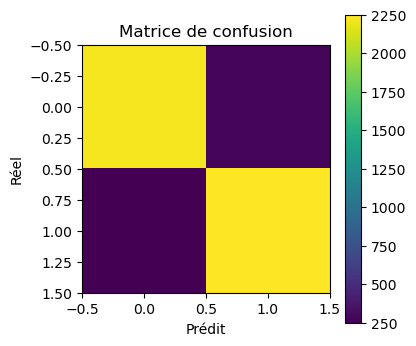

In [26]:
# Matrice de confusion
cm = confusion_matrix(y_test, y_pred_tfidf)
plt.figure(figsize=(4, 4))
plt.imshow(cm, interpolation='nearest')
plt.title("Matrice de confusion")
plt.colorbar()
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()

## 13. Analyse des erreurs

L’analyse des erreurs est une étape essentielle.

### À faire
Repérez quelques exemples :
- faux positifs ;
- faux négatifs ;
- cas ambigus ;
- textes contenant de la négation ;
- textes très courts ou très longs.

### Questions
- Les erreurs sont-elles aléatoires ?
- Les méthodes lexicales échouent-elles sur les mêmes cas que les embeddings ?
- BERT corrige-t-il vraiment les ambiguïtés observées plus tôt ?

## 14. Tableau comparatif final

Complétez un tableau récapitulatif avec vos résultats expérimentaux.

### Colonnes conseillées
- Méthode
- Type de représentation
- Accuracy
- F1 macro
- Temps d’exécution
- Avantages
- Limites

In [27]:
# Exemple de structure à compléter
resultats = pd.DataFrame([
    {
        "Méthode": "TF-IDF", 
        "Type": "Lexicale pondérée", 
        "Accuracy": 0.8944, 
        "F1_macro": 0.8943, 
        "Temps": "Très Rapide", 
        "Avantage": "Excellente séparation des mots-clés", 
        "Limite": "Ignore l'ordre des mots"
    },
    {
        "Méthode": "N-grams", 
        "Type": "Séquentielle courte", 
        "Accuracy": 0.8886, 
        "F1_macro": 0.8885, 
        "Temps": "Rapide", 
        "Avantage": "Capture les expressions courtes (ex: 'pas bon')", 
        "Limite": "Explosion de la dimensionnalité"
    },
    {
        "Méthode": "BoW", 
        "Type": "Lexicale", 
        "Accuracy": 0.8752, 
        "F1_macro": 0.8751, 
        "Temps": "Très Rapide", 
        "Avantage": "Simplicité extrême", 
        "Limite": "Donne trop de poids aux mots fréquents"
    },
    {
        "Méthode": "BERT", 
        "Type": "Embedding contextuel", 
        "Accuracy": 0.8375, 
        "F1_macro": 0.8367, 
        "Temps": "Lent (GPU requis)", 
        "Avantage": "Compréhension sémantique profonde", 
        "Limite": "Coûteux et nécessite beaucoup de données"
    },
    {
        "Méthode": "Word2Vec", 
        "Type": "Embedding statique", 
        "Accuracy": 0.8360, 
        "F1_macro": 0.8359, 
        "Temps": "Moyen", 
        "Avantage": "Capture les relations entre mots", 
        "Limite": "Sens unique pour chaque mot (polysemie)"
    },
    {
        "Méthode": "FastText", 
        "Type": "Embedding sous-mots", 
        "Accuracy": 0.8196, 
        "F1_macro": None, 
        "Temps": "Moyen", 
        "Avantage": "Gère les mots inconnus (fautes d'orthographe)", 
        "Limite": "Moins performant ici que le simple TF-IDF"
    },
])

resultats = resultats.sort_values(by="Accuracy", ascending=False)

display(resultats)


,Méthode,Type,Accuracy,F1_macro,Temps,Avantage,Limite
0,TF-IDF,Lexicale pondérée,0.8944,0.8943,Très Rapide,Excellente séparation des mots-clés,Ignore l'ordre des mots
1,N-grams,Séquentielle courte,0.8886,0.8885,Rapide,Capture les expressions courtes (ex: 'pas bon'),Explosion de la dimensionnalité
2,BoW,Lexicale,0.8752,0.8751,Très Rapide,Simplicité extrême,Donne trop de poids aux mots fréquents
3,BERT,Embedding contextuel,0.8375,0.8367,Lent (GPU requis),Compréhension sémantique profonde,Coûteux et nécessite beaucoup de données
4,Word2Vec,Embedding statique,0.8360,0.8359,Moyen,Capture les relations entre mots,Sens unique pour chaque mot (polysemie)
5,FastText,Embedding sous-mots,0.8196,NaN,Moyen,Gère les mots inconnus (fautes d'orthographe),Moins performant ici que le simple TF-IDF


## 15. Questions de synthèse

Rédigez une synthèse courte et structurée.

### À discuter
- Quelle méthode vous semble la plus adaptée à votre corpus ?
- La meilleure méthode est-elle la plus simple à interpréter ?
- Quel compromis choisiriez-vous entre précision, coût de calcul et explicabilité ?
- Si vous disposiez de plus de données, le classement des méthodes changerait-il selon vous ?